# Section 3: Exploratory Data Analysis (EDA)

## Mobile Money Transaction Analysis — User Classification

**Course:** CSC 3221 — Introduction to Data Science  
**Prediction Target:** Classify users into behavioral segments (Low / Medium / High activity)  
**Dataset:** 20,530 transactions from 69 users across MobileMoney and OrangeMoney operators  
**Date Range:** March 2023 – March 2026

---

### Notebook Outline

| Section | Title | Assessment Req. |
|---------|-------|-----------------|
| 1 | Setup & Data Loading | — |
| 2 | Descriptive Statistics | 3A |
| 3 | Distribution Plots | 3B-1, 3B-2 |
| 4 | Time Series Analysis | 3B-3 |
| 5 | Correlation Analysis | 3B-4 |
| 6 | Categorical Analysis | 3B-5 |
| 7 | Relationship Exploration (Scatter Plots) | 3B-6 |
| 8 | Grouped Comparisons | 3B-7 |
| 9 | Advanced Visualization & User Classification | 3B-8, Target Def. |
| 10 | Key Insights & Feature Relevance | 3C, 3D |

---

## Section 1: Setup & Data Loading

Import all required libraries, configure plotting defaults, and load the model-ready dataset produced by the Section 2 cleaning pipeline.

In [1]:
import sys, os, warnings
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

VIZ_DIR = Path('../3_EDA/visualizations')
VIZ_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = Path('../Data/output/model_ready_dataset.csv')
print(f"Visualization output: {VIZ_DIR.resolve()}")
print(f"Data source: {DATA_PATH.resolve()}")

Visualization output: C:\Users\ghisl\Documents\DataScience_Final_Project\3_EDA\visualizations
Data source: C:\Users\ghisl\Documents\DataScience_Final_Project\Data\output\model_ready_dataset.csv


In [2]:
df = pd.read_csv(DATA_PATH)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Date'] = pd.to_datetime(df['Date'])

print(f"Dataset shape: {df.shape}")
print(f"Unique users: {df['UserId'].nunique()}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nColumn types:\n{df.dtypes.to_string()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0].to_string()}")

Dataset shape: (20530, 24)
Unique users: 69
Date range: 2023-03-10 to 2026-03-28

Column types:
UserId                           object
Date                     datetime64[ns]
Heure                            object
Operator                         object
Transaction_type                 object
Direction                        object
Amount                          float64
Currency                         object
New_balance                     float64
Anonymized_Content               object
Datetime                 datetime64[ns]
is_outlier                         bool
data_source                      object
year                              int64
month                             int64
day                               int64
weekday                           int64
hour                              int64
is_weekend                        int64
net_amount                      float64
days_since_last_txn             float64
monthly_txn_frequency           float64
send_receive_ratio      

---

## Section 2: Descriptive Statistics

Summary statistics for all key numerical and categorical variables, including distribution measures (mean, median, standard deviation, skewness) and cross-tabulations between categorical variables.

This section satisfies **Requirement 3A**: *Summary statistics for all key variables, distribution analysis, and cross-tabulations for categorical variables.*

In [3]:
numerical_cols = ['Amount', 'New_balance', 'net_amount', 'days_since_last_txn',
                  'monthly_txn_frequency', 'send_receive_ratio', 'txn_velocity_7d']

desc = df[numerical_cols].describe().T
desc['skewness'] = df[numerical_cols].skew()
desc['median'] = df[numerical_cols].median()
desc = desc[['count', 'mean', 'median', 'std', 'min', '25%', '75%', 'max', 'skewness']]
print("=== Numerical Variable Summary ===")
desc.round(2)

=== Numerical Variable Summary ===


,count,mean,median,std,min,25%,75%,max,skewness
Amount,20530.0,7454.20,500.00,33702.31,0.00,200.00,2000.00,825575.00,8.23
New_balance,20473.0,20362.24,2653.00,59198.93,0.00,474.00,14154.00,889721.00,5.61
net_amount,20530.0,145.46,-250.00,34516.55,-500000.00,-600.00,-25.00,825575.00,0.61
days_since_last_txn,20461.0,0.70,0.13,3.74,0.00,0.02,0.58,292.34,39.93
monthly_txn_frequency,20530.0,131.12,56.16,149.15,1.25,33.78,127.36,418.50,1.30
send_receive_ratio,20530.0,3.95,3.48,2.17,0.00,2.99,4.77,39.00,3.38
txn_velocity_7d,20530.0,39.30,19.00,48.85,1.00,10.00,39.00,274.00,2.08


In [4]:
print("=== Categorical Variable Distributions ===\n")
for col in ['Operator', 'Transaction_type', 'Direction', 'Currency', 'data_source']:
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True).mul(100).round(1)
    summary = pd.DataFrame({'Count': counts, 'Percent': pcts})
    print(f"--- {col} ---")
    print(summary.to_string())
    print()

=== Categorical Variable Distributions ===

--- Operator ---
             Count  Percent
Operator                   
MobileMoney  19766     96.3
OrangeMoney    764      3.7

--- Transaction_type ---
                  Count  Percent
Transaction_type                
transfert          6592     32.1
transaction        5104     24.9
airtime            3502     17.1
paiement           2637     12.8
retrait            2487     12.1
depot               208      1.0

--- Direction ---
           Count  Percent
Direction                
OUT        15920     77.5
IN          4610     22.5

--- Currency ---
          Count  Percent
Currency                
XAF       20530    100.0

--- data_source ---
             Count  Percent
data_source                
original     19261     93.8
anonymized    1269      6.2



In [5]:
print("=== Cross-Tabulations ===\n")

print("--- Transaction Type \u00d7 Direction ---")
ct1 = pd.crosstab(df['Transaction_type'], df['Direction'], margins=True)
print(ct1.to_string())
print()

print("--- Transaction Type \u00d7 Operator ---")
ct2 = pd.crosstab(df['Transaction_type'], df['Operator'], margins=True)
print(ct2.to_string())
print()

print("--- Direction \u00d7 Data Source ---")
ct3 = pd.crosstab(df['Direction'], df['data_source'], margins=True)
print(ct3.to_string())

=== Cross-Tabulations ===

--- Transaction Type × Direction ---


Direction           IN    OUT    All
Transaction_type                    
airtime              0   3502   3502
depot              208      0    208
paiement             0   2637   2637
retrait              0   2487   2487
transaction          0   5104   5104
transfert         4402   2190   6592
All               4610  15920  20530



--- Transaction Type × Operator ---
Operator          MobileMoney  OrangeMoney    All
Transaction_type                                 
airtime                  3217          285   3502
depot                       0          208    208
paiement                 2636            1   2637
retrait                  2234          253   2487
transaction              5104            0   5104
transfert                6575           17   6592
All                     19766          764  20530

--- Direction × Data Source ---


data_source  anonymized  original    All
Direction                               
IN                  374      4236   4610
OUT                 895     15025  15920
All                1269     19261  20530


---

## Section 3: Distribution Plots

Histograms with kernel density estimation (KDE) overlays for key numerical variables, and box plots showing the spread and outlier presence across transaction categories.

This section satisfies **Requirements 3B-1** (distribution/density plots) and **3B-2** (box plots showing outliers and spread).

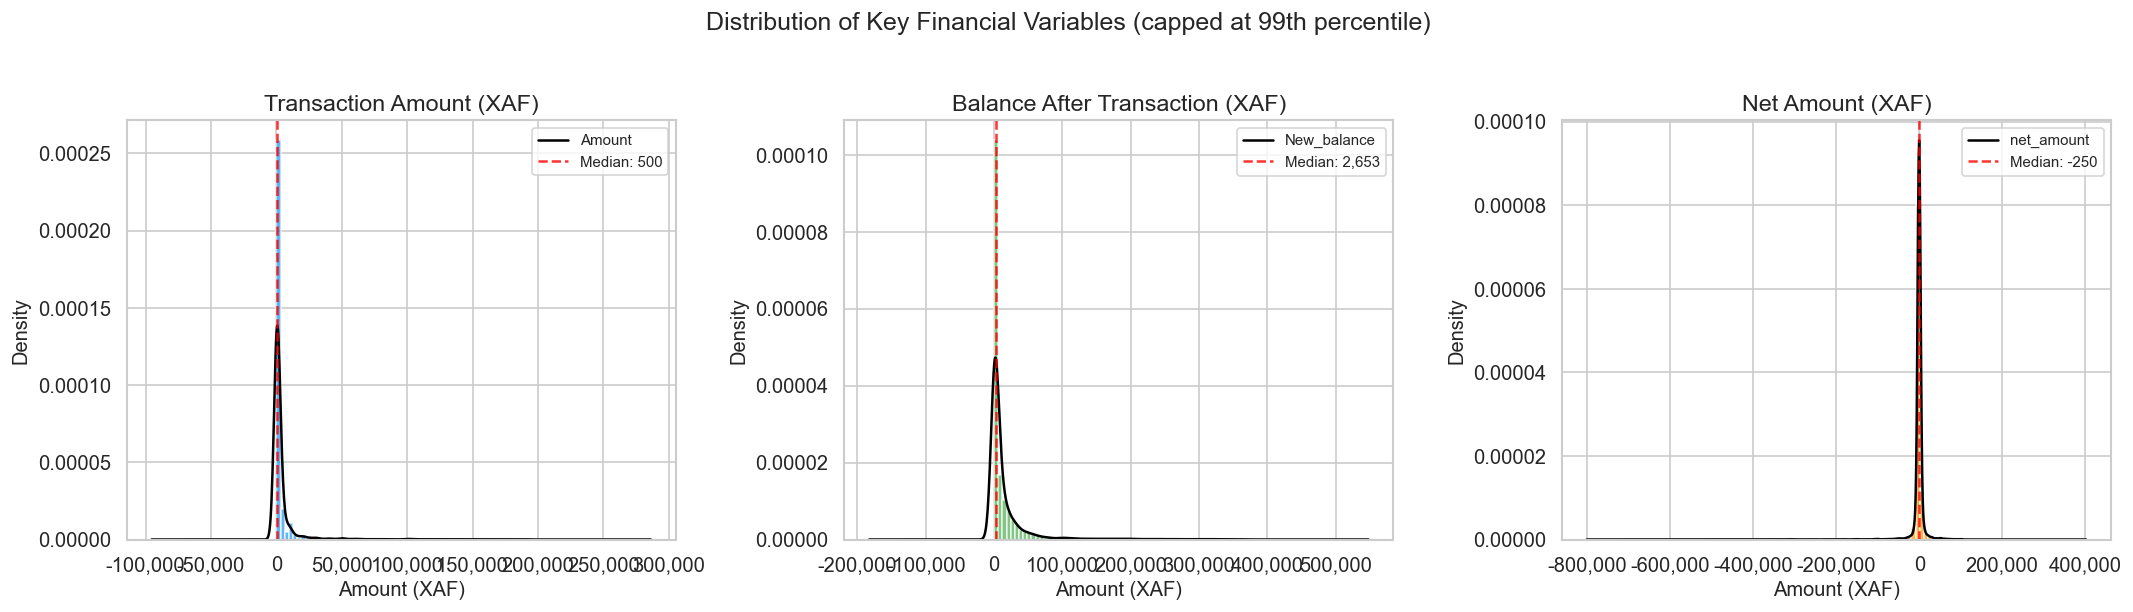

Saved: 01_amount_distributions.png


In [6]:
# Visualization 1: Histograms + KDE for Amount, New_balance, net_amount
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title, color in zip(
    axes,
    ['Amount', 'New_balance', 'net_amount'],
    ['Transaction Amount (XAF)', 'Balance After Transaction (XAF)', 'Net Amount (XAF)'],
    ['#2196F3', '#4CAF50', '#FF9800']
):
    data = df[col].dropna()
    cap = data.quantile(0.99)
    data_capped = data[data <= cap]
    ax.hist(data_capped, bins=60, color=color, alpha=0.7, edgecolor='white', density=True)
    data_capped.plot.kde(ax=ax, color='black', linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel('Amount (XAF)')
    ax.set_ylabel('Density')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.axvline(data.median(), color='red', linestyle='--', alpha=0.8, label=f'Median: {data.median():,.0f}')
    ax.legend(fontsize=9)

fig.suptitle('Distribution of Key Financial Variables (capped at 99th percentile)', fontsize=15, y=1.02)
plt.tight_layout()
fig.savefig(VIZ_DIR / '01_amount_distributions.png')
plt.show()
print("Saved: 01_amount_distributions.png")

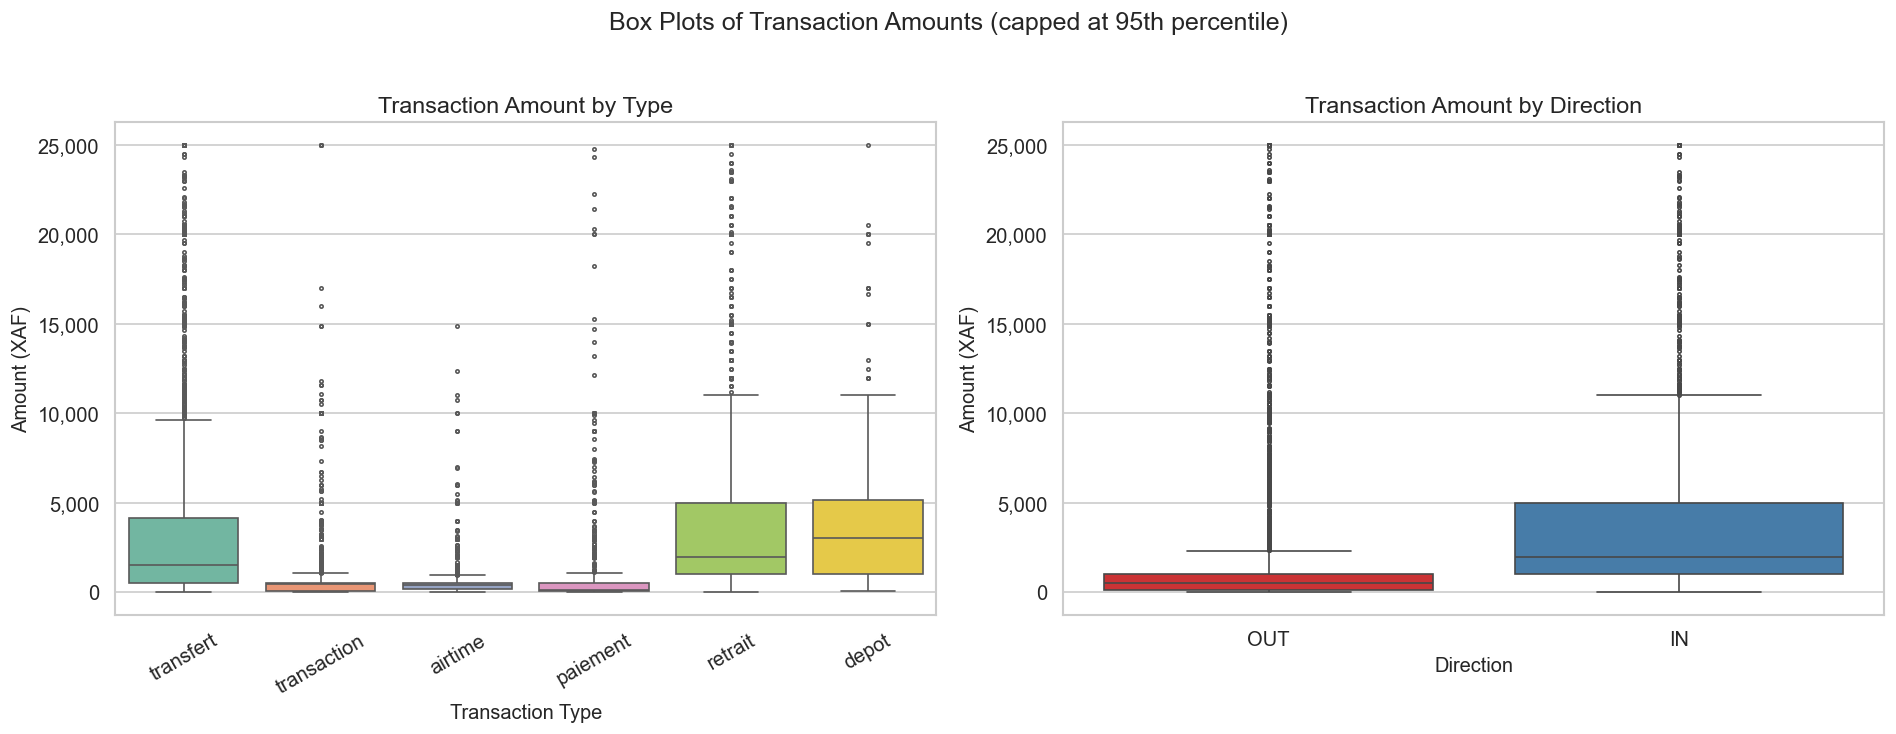

Saved: 02_amount_boxplots.png


In [7]:
# Visualization 2: Box plots — Amount by Transaction Type and by Direction
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cap = df['Amount'].quantile(0.95)
df_capped = df[df['Amount'] <= cap]

type_order = df['Transaction_type'].value_counts().index.tolist()
sns.boxplot(data=df_capped, x='Transaction_type', y='Amount', order=type_order,
            palette='Set2', ax=axes[0], fliersize=2)
axes[0].set_title('Transaction Amount by Type')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Amount (XAF)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

sns.boxplot(data=df_capped, x='Direction', y='Amount', palette='Set1', ax=axes[1], fliersize=2)
axes[1].set_title('Transaction Amount by Direction')
axes[1].set_xlabel('Direction')
axes[1].set_ylabel('Amount (XAF)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Box Plots of Transaction Amounts (capped at 95th percentile)', fontsize=15, y=1.02)
plt.tight_layout()
fig.savefig(VIZ_DIR / '02_amount_boxplots.png')
plt.show()
print("Saved: 02_amount_boxplots.png")

---

## Section 4: Time Series Analysis

Analysis of transaction patterns over time, including monthly volume trends and hourly activity distribution. These temporal patterns reveal when users are most active and how transaction behavior evolves.

This section satisfies **Requirement 3B-3**: *Time series plots (transaction patterns over time).*

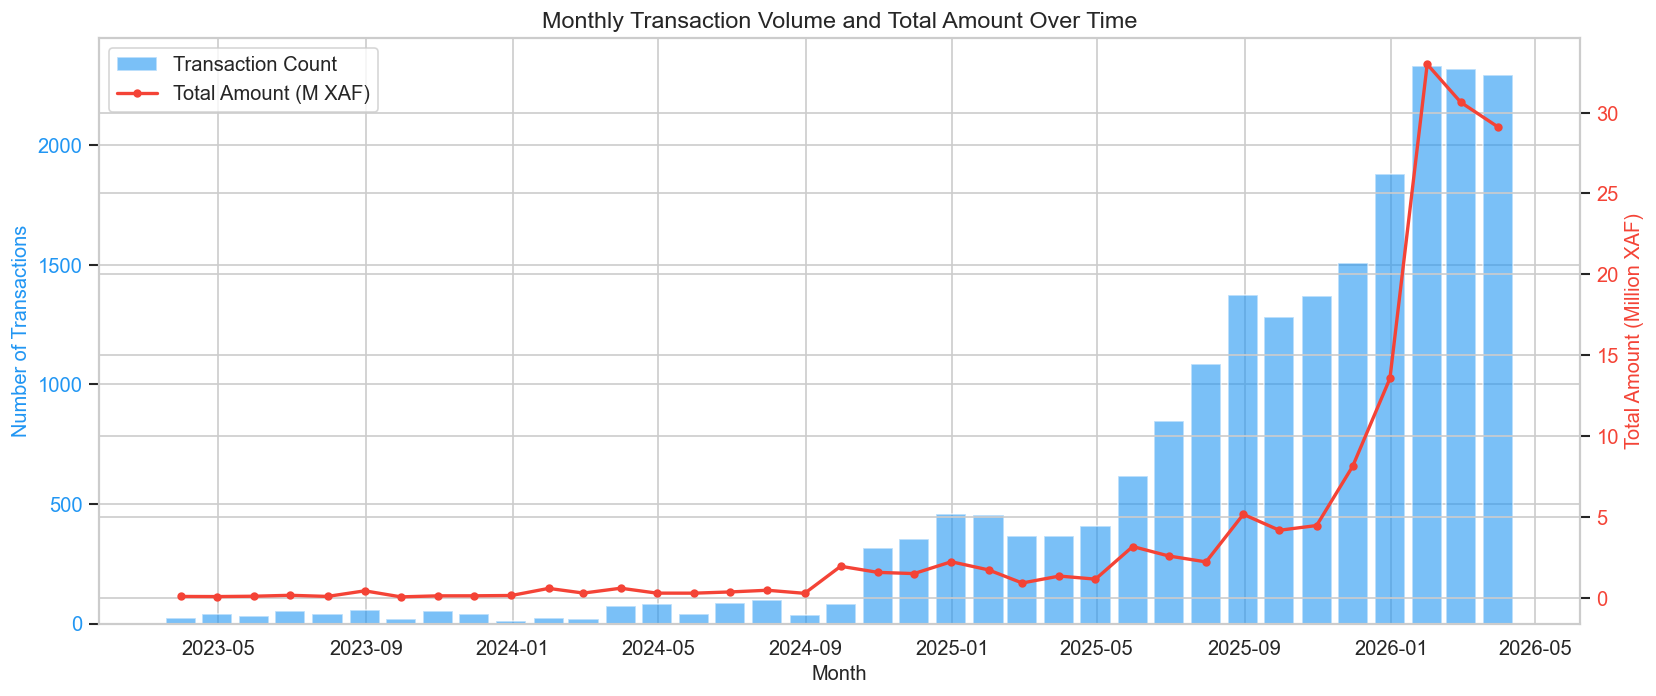

Saved: 03_monthly_time_series.png


In [8]:
# Visualization 3: Monthly transaction volume and total amount over time
monthly = df.set_index('Datetime').resample('M').agg(
    txn_count=('Amount', 'count'),
    total_amount=('Amount', 'sum'),
    avg_amount=('Amount', 'mean'),
    unique_users=('UserId', 'nunique')
)

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#2196F3'
ax1.bar(monthly.index, monthly['txn_count'], width=25, color=color1, alpha=0.6, label='Transaction Count')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Transactions', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#F44336'
ax2.plot(monthly.index, monthly['total_amount'] / 1e6, color=color2, linewidth=2, marker='o', markersize=4, label='Total Amount (M XAF)')
ax2.set_ylabel('Total Amount (Million XAF)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Monthly Transaction Volume and Total Amount Over Time')
fig.tight_layout()
fig.savefig(VIZ_DIR / '03_monthly_time_series.png')
plt.show()
print("Saved: 03_monthly_time_series.png")

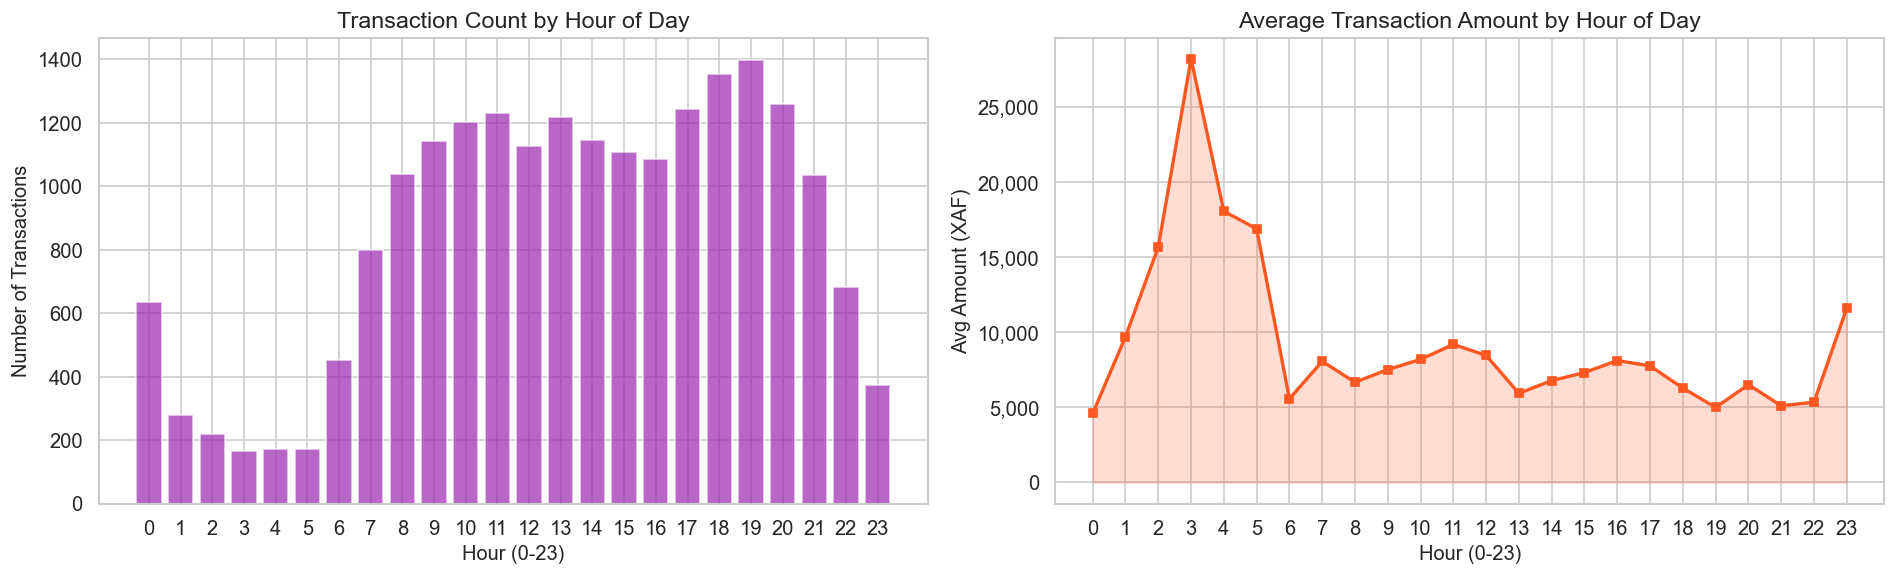

Saved: 04_hourly_distribution.png


In [9]:
# Visualization 4: Hourly transaction distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly_counts = df['hour'].value_counts().sort_index()
axes[0].bar(hourly_counts.index, hourly_counts.values, color='#9C27B0', alpha=0.7, edgecolor='white')
axes[0].set_title('Transaction Count by Hour of Day')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks(range(0, 24))

hourly_amount = df.groupby('hour')['Amount'].mean()
axes[1].plot(hourly_amount.index, hourly_amount.values, color='#FF5722', linewidth=2, marker='s', markersize=5)
axes[1].fill_between(hourly_amount.index, hourly_amount.values, alpha=0.2, color='#FF5722')
axes[1].set_title('Average Transaction Amount by Hour of Day')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Avg Amount (XAF)')
axes[1].set_xticks(range(0, 24))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
fig.savefig(VIZ_DIR / '04_hourly_distribution.png')
plt.show()
print("Saved: 04_hourly_distribution.png")

---

## Section 5: Correlation Analysis

A correlation heatmap showing relationships between all numerical features in the dataset. This identifies multicollinearity between features and highlights which variables co-vary — critical for selecting non-redundant predictive features for the classification model.

This section satisfies **Requirement 3B-4**: *Correlation heatmap (relationships between numerical variables).*

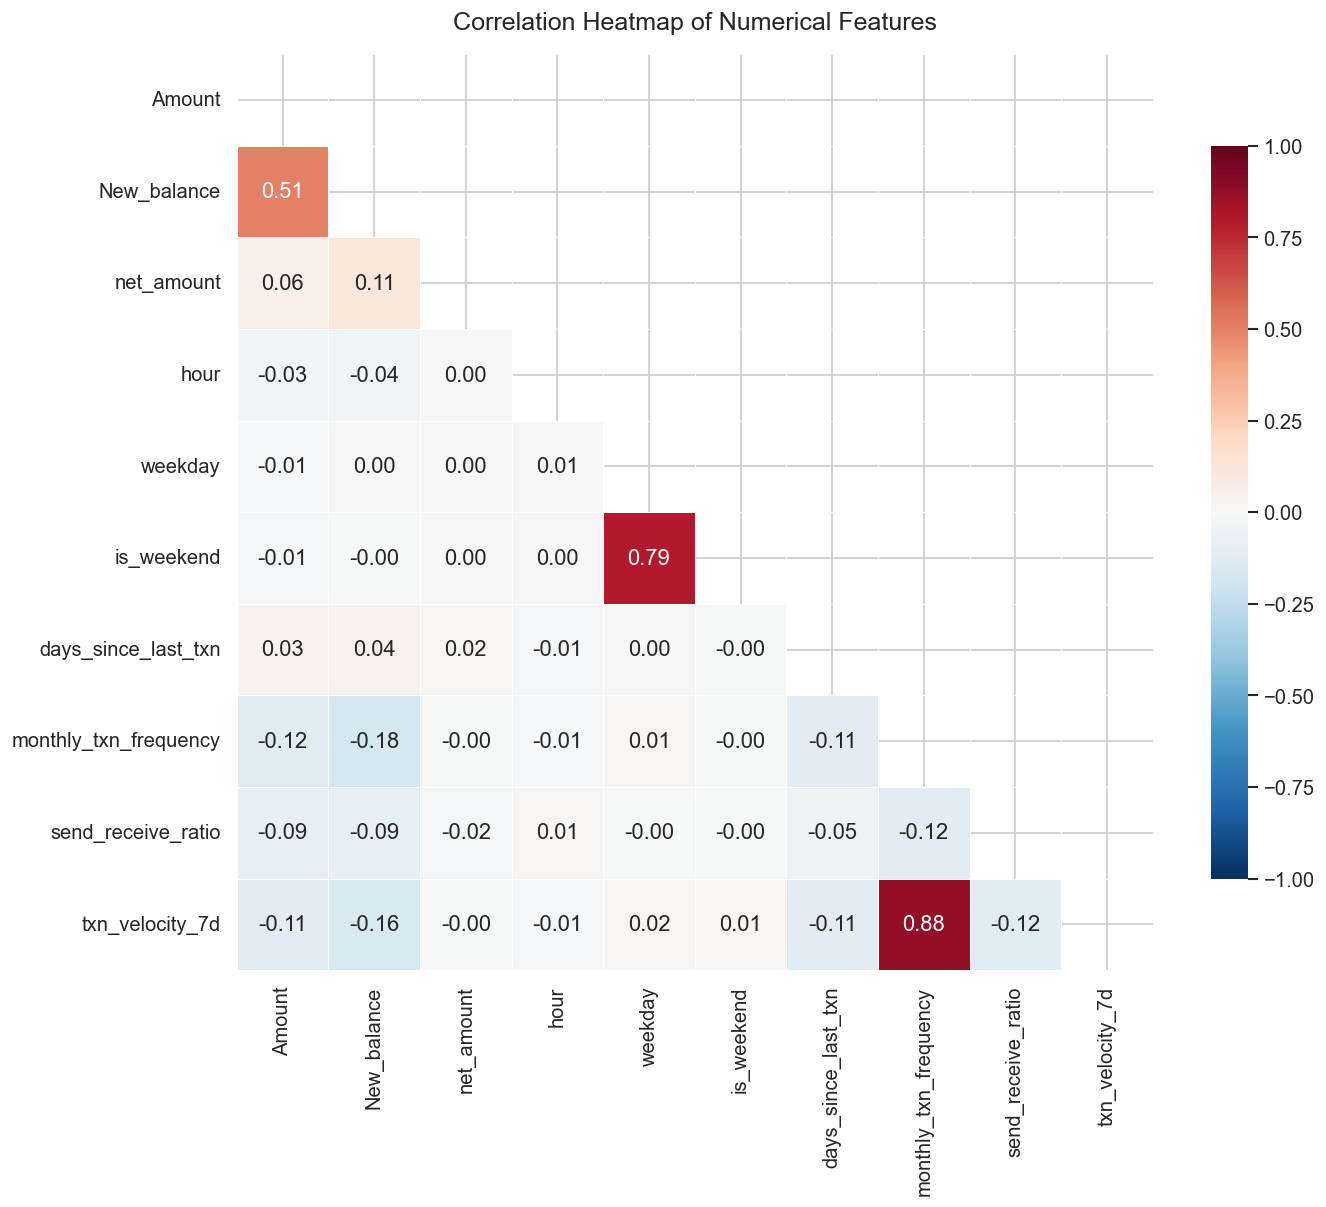

Saved: 05_correlation_heatmap.png

Strongest correlations (|r| > 0.3):
  monthly_txn_frequency <-> txn_velocity_7d: r=0.880
  weekday <-> is_weekend: r=0.791
  Amount <-> New_balance: r=0.507


In [10]:
# Visualization 5: Correlation heatmap
corr_cols = ['Amount', 'New_balance', 'net_amount', 'hour', 'weekday',
             'is_weekend', 'days_since_last_txn', 'monthly_txn_frequency',
             'send_receive_ratio', 'txn_velocity_7d']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=15, pad=15)
plt.tight_layout()
fig.savefig(VIZ_DIR / '05_correlation_heatmap.png')
plt.show()
print("Saved: 05_correlation_heatmap.png")

print("\nStrongest correlations (|r| > 0.3):")
pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], r))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, r in pairs:
    print(f"  {a} <-> {b}: r={r:.3f}")

---

## Section 6: Categorical Analysis

Bar charts for all categorical variables — transaction types, transaction direction (IN/OUT), mobile money operator, and data source. These visualizations reveal the composition of the dataset and highlight dominant categories.

This section satisfies **Requirement 3B-5**: *Bar charts for categorical variables (profession, zone, transaction types).*

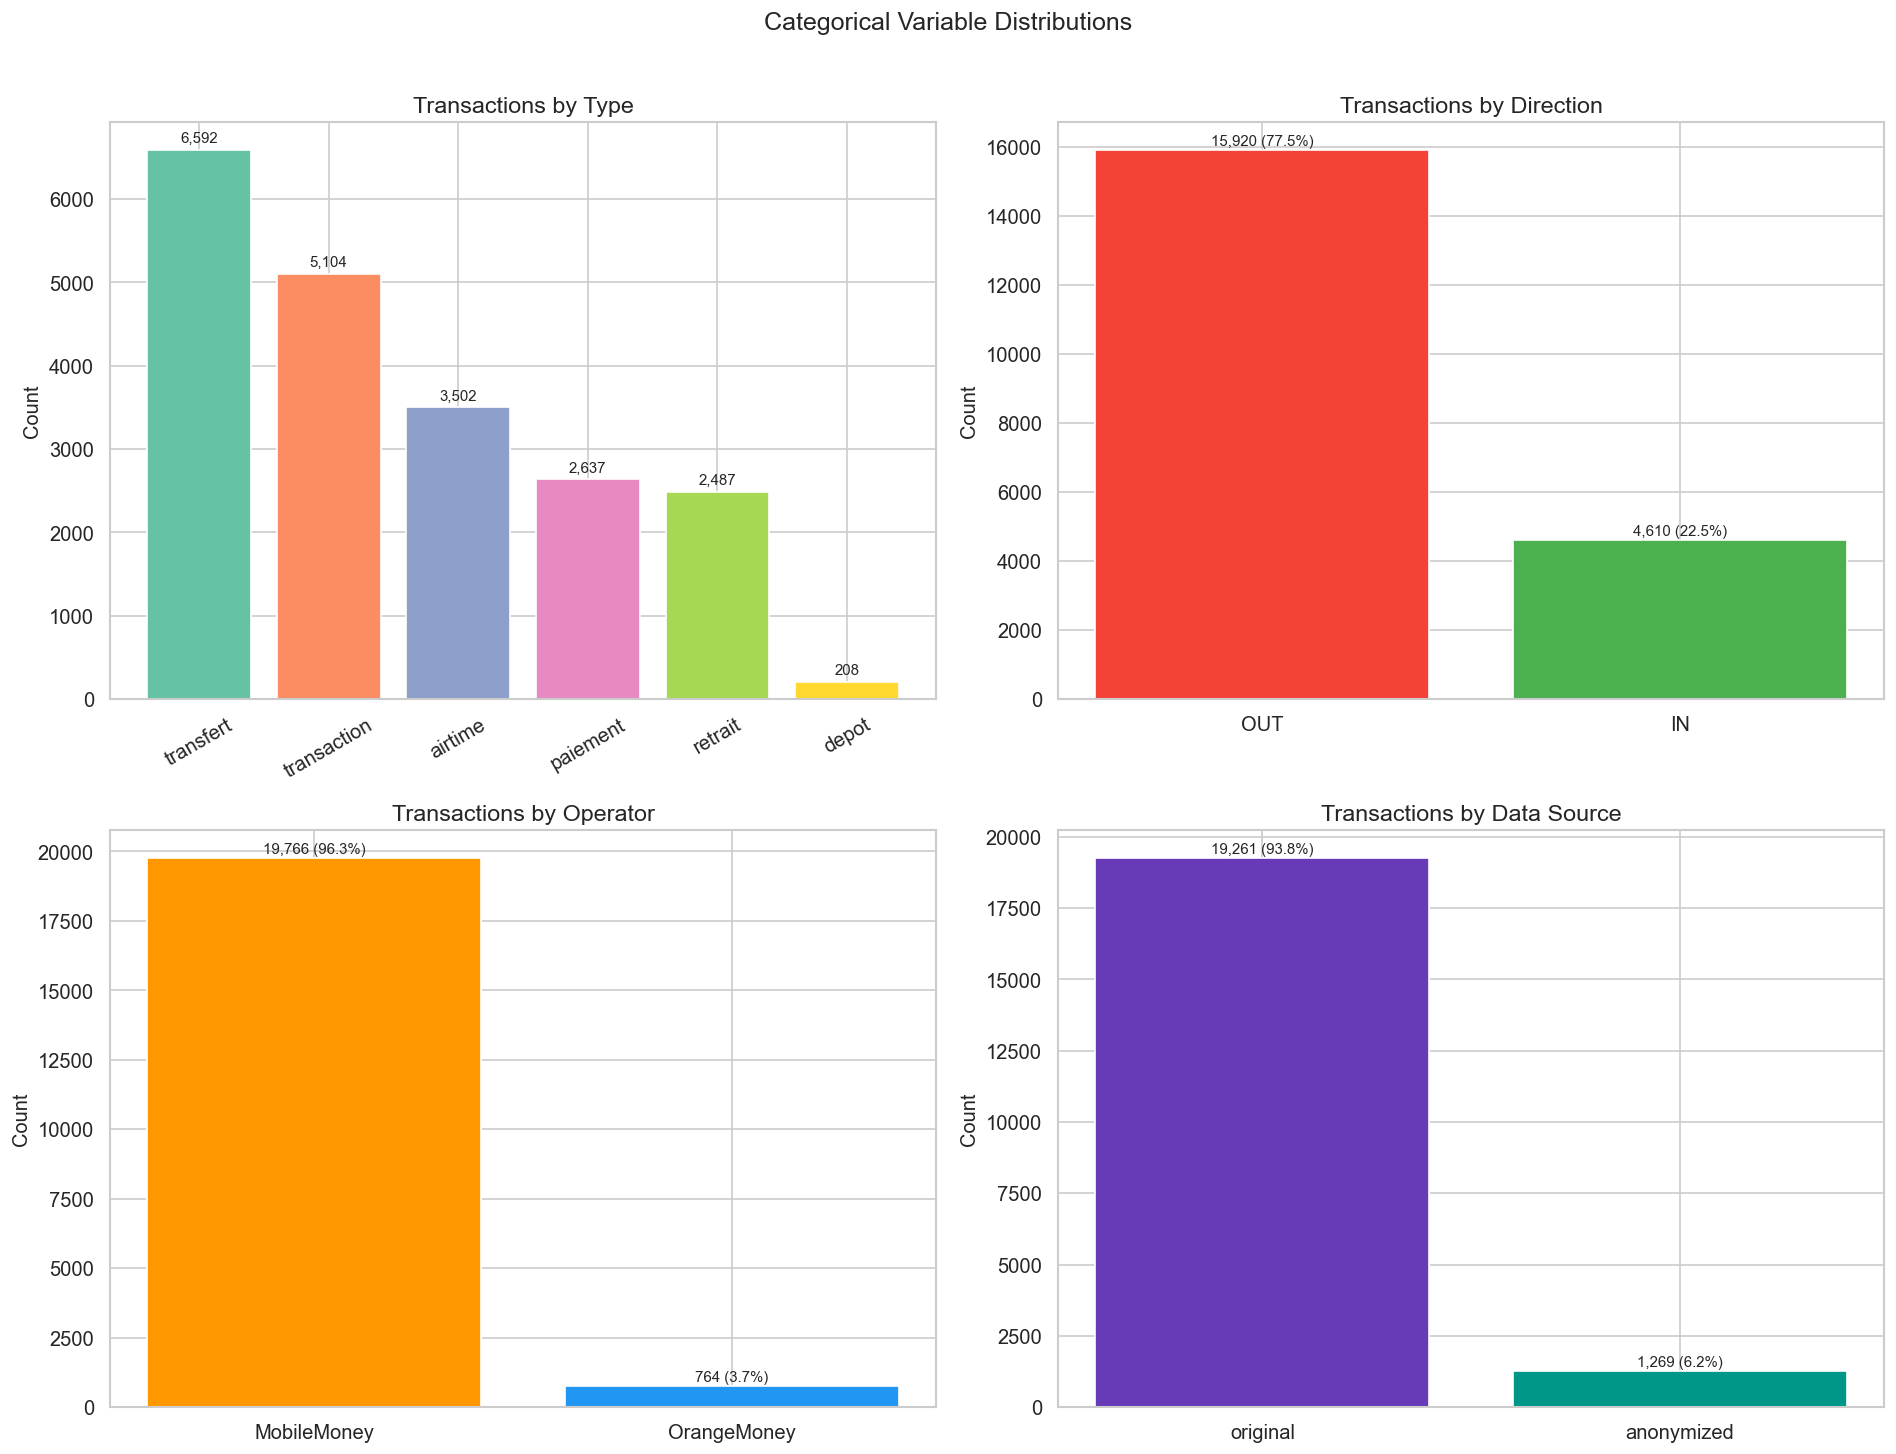

Saved: 06_categorical_barcharts.png


In [11]:
# Visualization 6: Bar charts for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Transaction Type
type_counts = df['Transaction_type'].value_counts()
bars = axes[0, 0].bar(type_counts.index, type_counts.values, color=sns.color_palette('Set2', len(type_counts)),
                       edgecolor='white')
axes[0, 0].set_title('Transactions by Type')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, type_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                     f'{val:,}', ha='center', va='bottom', fontsize=9)

# Direction
dir_counts = df['Direction'].value_counts()
colors_dir = ['#F44336', '#4CAF50']
bars = axes[0, 1].bar(dir_counts.index, dir_counts.values, color=colors_dir, edgecolor='white')
axes[0, 1].set_title('Transactions by Direction')
axes[0, 1].set_ylabel('Count')
for bar, val in zip(bars, dir_counts.values):
    pct = val / len(df) * 100
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                     f'{val:,} ({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# Operator
op_counts = df['Operator'].value_counts()
bars = axes[1, 0].bar(op_counts.index, op_counts.values, color=['#FF9800', '#2196F3'], edgecolor='white')
axes[1, 0].set_title('Transactions by Operator')
axes[1, 0].set_ylabel('Count')
for bar, val in zip(bars, op_counts.values):
    pct = val / len(df) * 100
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                     f'{val:,} ({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

# Data Source
src_counts = df['data_source'].value_counts()
bars = axes[1, 1].bar(src_counts.index, src_counts.values, color=['#673AB7', '#009688'], edgecolor='white')
axes[1, 1].set_title('Transactions by Data Source')
axes[1, 1].set_ylabel('Count')
for bar, val in zip(bars, src_counts.values):
    pct = val / len(df) * 100
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                     f'{val:,} ({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

fig.suptitle('Categorical Variable Distributions', fontsize=15, y=1.01)
plt.tight_layout()
fig.savefig(VIZ_DIR / '06_categorical_barcharts.png')
plt.show()
print("Saved: 06_categorical_barcharts.png")

---

## Section 7: Relationship Exploration (Scatter Plots)

Scatter plots at the **user level** to explore relationships between behavioral features. We first aggregate transaction-level data into per-user profiles, then visualize how features like transaction count, mean amount, monthly frequency, and balance relate to each other. These per-user aggregations directly inform the user classification model.

This section satisfies **Requirement 3B-6**: *Scatter plots exploring relationships (e.g., income vs. transaction volume).*

In [12]:
# Build per-user feature table for scatter plots and classification
user_agg = df.groupby('UserId').agg(
    txn_count=('Amount', 'count'),
    total_amount=('Amount', 'sum'),
    mean_amount=('Amount', 'mean'),
    median_amount=('Amount', 'median'),
    std_amount=('Amount', 'std'),
    total_in=('net_amount', lambda x: x[x > 0].sum()),
    total_out=('net_amount', lambda x: abs(x[x < 0].sum())),
    avg_balance=('New_balance', 'mean'),
    n_months=('month', 'nunique'),
    avg_monthly_freq=('monthly_txn_frequency', 'mean'),
    avg_sr_ratio=('send_receive_ratio', 'mean'),
    avg_velocity_7d=('txn_velocity_7d', 'mean'),
    pct_weekend=('is_weekend', 'mean'),
    operator=('Operator', lambda x: x.mode()[0]),
    data_source=('data_source', 'first'),
).reset_index()

user_agg['monthly_txn_count'] = user_agg['txn_count'] / user_agg['n_months'].clip(lower=1)

print(f"User-level aggregation: {user_agg.shape}")
user_agg.head()

User-level aggregation: (69, 17)

,UserId,txn_count,total_amount,mean_amount,median_amount,std_amount,total_in,total_out,avg_balance,n_months,avg_monthly_freq,avg_sr_ratio,avg_velocity_7d,pct_weekend,operator,data_source,monthly_txn_count
0,anon_user0001,54,5866645.0,108641.574074,53992.0,120208.073031,3825111.0,2041534.0,260804.148148,4,13.50,1.367545,4.870370,0.314815,MobileMoney,anonymized,13.50
1,anon_user0002,56,8261267.0,147522.625000,122466.5,125679.559219,4118942.0,4142325.0,252197.035714,4,14.00,1.365709,5.053571,0.178571,MobileMoney,anonymized,14.00
2,anon_user0003,65,7086427.0,109021.953846,76436.0,111538.140038,3258996.0,3827431.0,236012.538462,4,16.25,2.721998,5.400000,0.384615,MobileMoney,anonymized,16.25
3,anon_user0004,54,5233206.0,96911.222222,61464.5,104776.521525,2655170.0,2578036.0,251558.981481,4,13.50,2.578198,5.166667,0.222222,MobileMoney,anonymized,13.50
4,anon_user0005,53,5235787.0,98788.433962,67199.0,99626.845445,2109117.0,3126670.0,254809.094340,4,13.25,1.690372,4.886792,0.283019,MobileMoney,anonymized,13.25


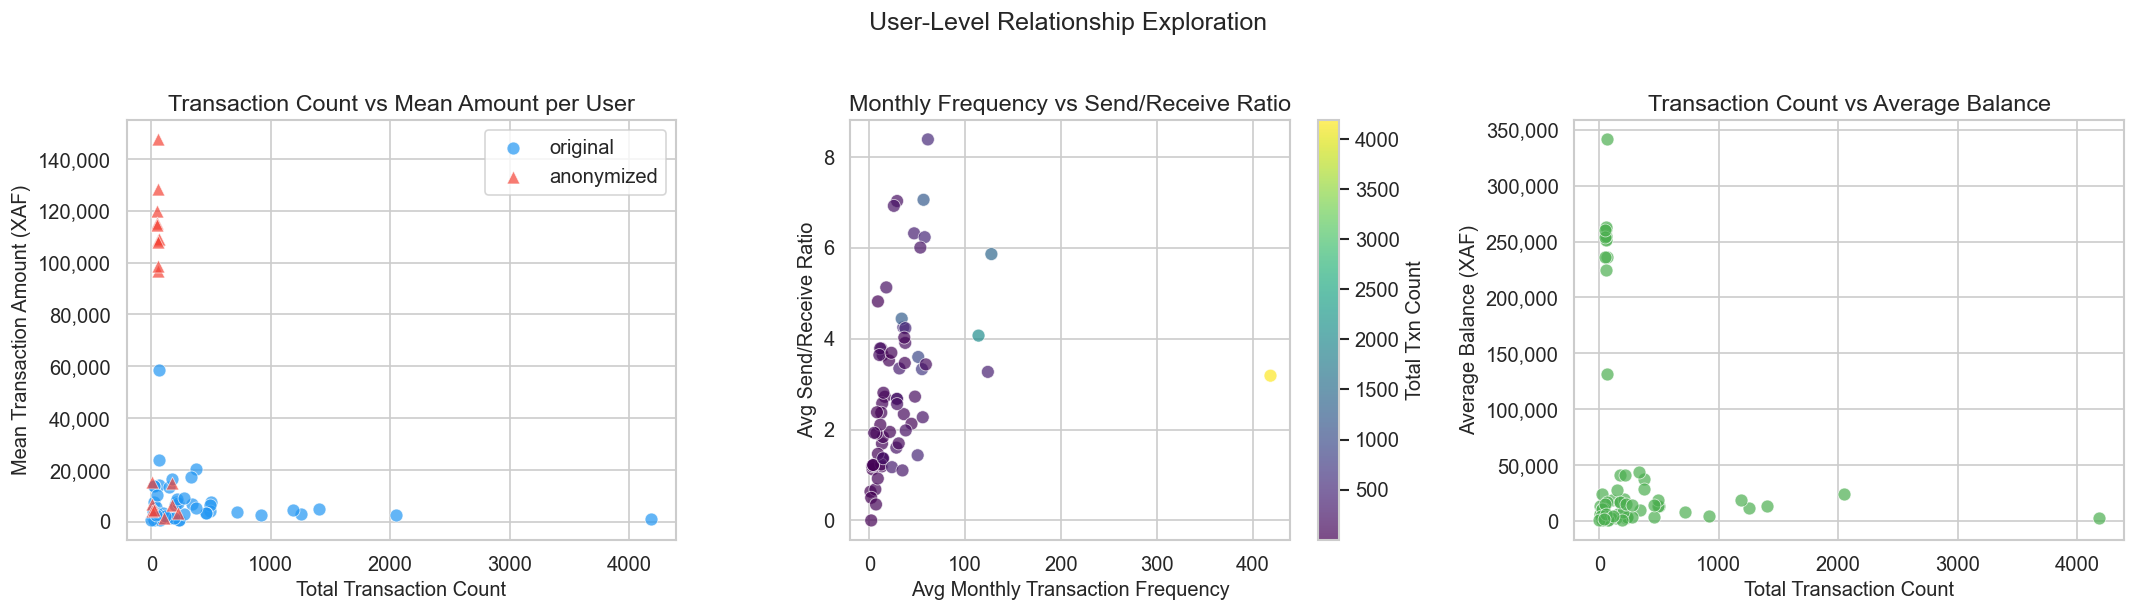

Saved: 07_scatter_relationships.png


In [13]:
# Visualization 7: Scatter plots — user-level relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Transaction count vs mean amount
for src, marker, color in [('original', 'o', '#2196F3'), ('anonymized', '^', '#F44336')]:
    subset = user_agg[user_agg['data_source'] == src]
    axes[0].scatter(subset['txn_count'], subset['mean_amount'], c=color, marker=marker,
                    alpha=0.7, s=60, label=src, edgecolors='white', linewidth=0.5)
axes[0].set_title('Transaction Count vs Mean Amount per User')
axes[0].set_xlabel('Total Transaction Count')
axes[0].set_ylabel('Mean Transaction Amount (XAF)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].legend()

# Monthly frequency vs send/receive ratio
axes[1].scatter(user_agg['avg_monthly_freq'], user_agg['avg_sr_ratio'],
                c=user_agg['txn_count'], cmap='viridis', s=60, alpha=0.7, edgecolors='white', linewidth=0.5)
axes[1].set_title('Monthly Frequency vs Send/Receive Ratio')
axes[1].set_xlabel('Avg Monthly Transaction Frequency')
axes[1].set_ylabel('Avg Send/Receive Ratio')
cb = plt.colorbar(axes[1].collections[0], ax=axes[1])
cb.set_label('Total Txn Count')

# Average balance vs transaction count
axes[2].scatter(user_agg['txn_count'], user_agg['avg_balance'],
                c='#4CAF50', s=60, alpha=0.7, edgecolors='white', linewidth=0.5)
axes[2].set_title('Transaction Count vs Average Balance')
axes[2].set_xlabel('Total Transaction Count')
axes[2].set_ylabel('Average Balance (XAF)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('User-Level Relationship Exploration', fontsize=15, y=1.02)
plt.tight_layout()
fig.savefig(VIZ_DIR / '07_scatter_relationships.png')
plt.show()
print("Saved: 07_scatter_relationships.png")

---

## Section 8: Grouped Comparisons

Comparing transaction behavior across key grouping variables: mobile money operator (MobileMoney vs OrangeMoney), transaction direction (IN vs OUT), data source (original vs anonymized), and weekday vs weekend usage. These comparisons reveal whether behavioral differences exist between sub-populations.

This section satisfies **Requirement 3B-7**: *Grouped comparisons (e.g., transaction behavior by profession or zone).*

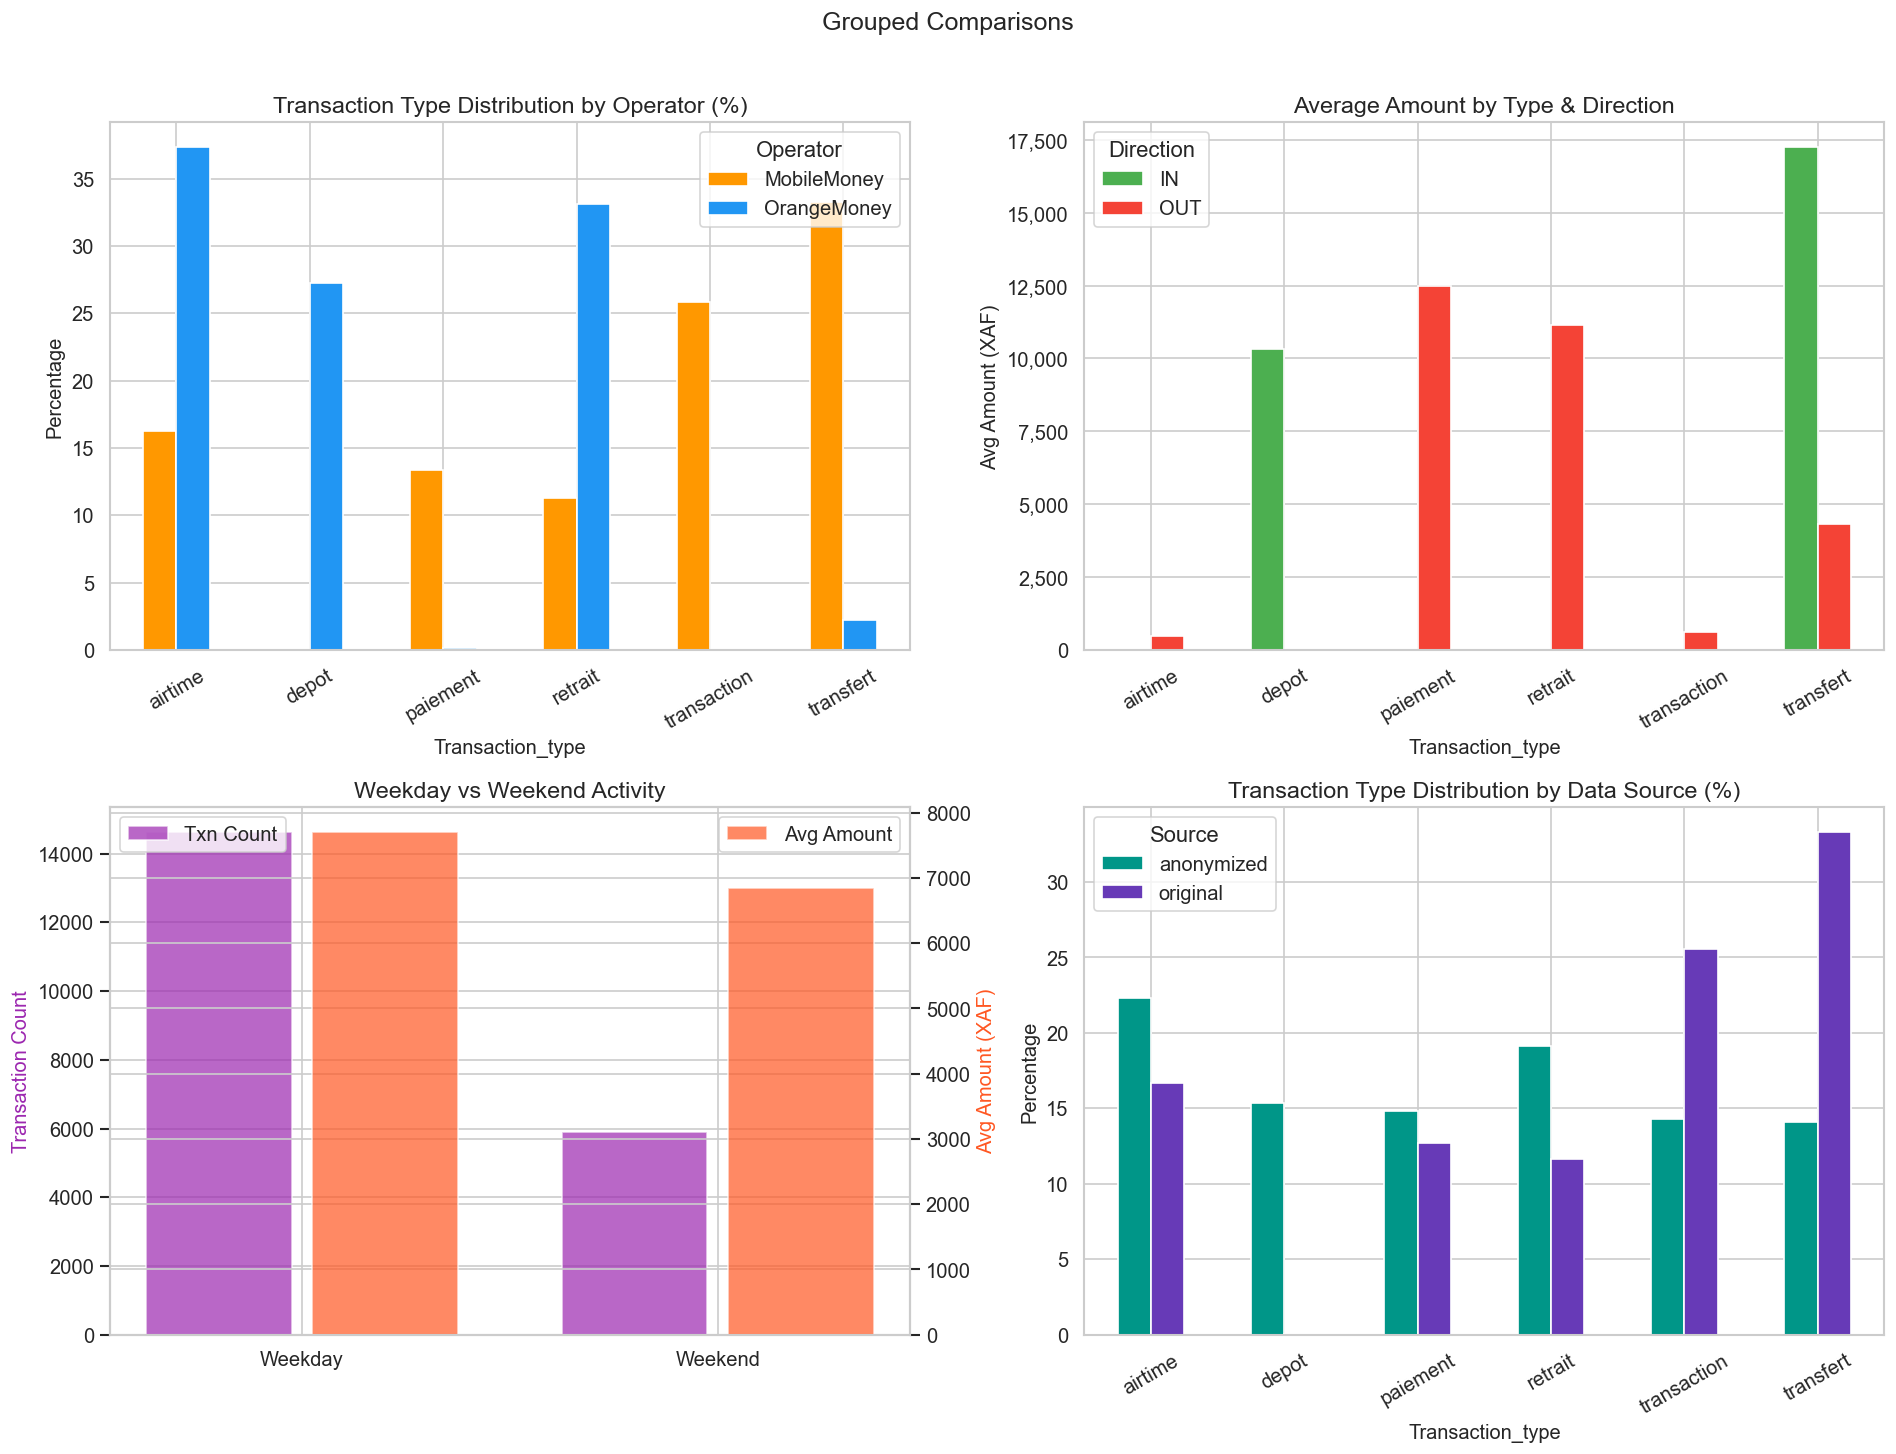

Saved: 08_grouped_comparisons.png


In [14]:
# Visualization 8: Grouped comparisons
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 8a: Transaction type distribution by Operator
ct_op = pd.crosstab(df['Transaction_type'], df['Operator'], normalize='columns').mul(100)
ct_op.plot(kind='bar', ax=axes[0, 0], color=['#FF9800', '#2196F3'], edgecolor='white')
axes[0, 0].set_title('Transaction Type Distribution by Operator (%)')
axes[0, 0].set_ylabel('Percentage')
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].legend(title='Operator')

# 8b: Average amount by Transaction type and Direction
amt_by_type_dir = df.groupby(['Transaction_type', 'Direction'])['Amount'].mean().unstack(fill_value=0)
amt_by_type_dir.plot(kind='bar', ax=axes[0, 1], color=['#4CAF50', '#F44336'], edgecolor='white')
axes[0, 1].set_title('Average Amount by Type & Direction')
axes[0, 1].set_ylabel('Avg Amount (XAF)')
axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0, 1].legend(title='Direction')

# 8c: Weekday vs Weekend — transaction count and avg amount
wk_labels = ['Weekday', 'Weekend']
wk_counts = df.groupby('is_weekend').size()
wk_amounts = df.groupby('is_weekend')['Amount'].mean()

x = np.arange(2)
bars1 = axes[1, 0].bar(x - 0.2, wk_counts.values, 0.35, label='Txn Count', color='#9C27B0', alpha=0.7)
ax_r = axes[1, 0].twinx()
bars2 = ax_r.bar(x + 0.2, wk_amounts.values, 0.35, label='Avg Amount', color='#FF5722', alpha=0.7)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(wk_labels)
axes[1, 0].set_ylabel('Transaction Count', color='#9C27B0')
ax_r.set_ylabel('Avg Amount (XAF)', color='#FF5722')
axes[1, 0].set_title('Weekday vs Weekend Activity')
axes[1, 0].legend(loc='upper left')
ax_r.legend(loc='upper right')

# 8d: Transaction type breakdown by data source
ct_src = pd.crosstab(df['Transaction_type'], df['data_source'], normalize='columns').mul(100)
ct_src.plot(kind='bar', ax=axes[1, 1], color=['#009688', '#673AB7'], edgecolor='white')
axes[1, 1].set_title('Transaction Type Distribution by Data Source (%)')
axes[1, 1].set_ylabel('Percentage')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].legend(title='Source')

fig.suptitle('Grouped Comparisons', fontsize=15, y=1.01)
plt.tight_layout()
fig.savefig(VIZ_DIR / '08_grouped_comparisons.png')
plt.show()
print("Saved: 08_grouped_comparisons.png")

---

## Section 9: Advanced Visualization & User Classification

### 9.1 Advanced Visualization

A user activity heatmap (hour of day × day of week) showing when mobile money transactions peak across the entire dataset. This type of heatmap goes beyond standard charts by encoding two temporal dimensions simultaneously.

### 9.2 User Classification Definition

Users are classified into three behavioral segments using **quantile-based thresholds** on total transaction count:

| Class | Definition | Business Meaning |
|-------|------------|------------------|
| **Low Activity** | Bottom tercile (≤ 33rd percentile) | Casual users — occasional personal transfers, minimal engagement |
| **Medium Activity** | Middle tercile (34th–66th percentile) | Regular users — consistent weekly usage for payments and transfers |
| **High Activity** | Top tercile (> 66th percentile) | Power users / agents — daily intensive transaction patterns |

### 9.3 Why 3 Classes (Not 2 or 4)?

- **Business relevance:** Financial service providers typically segment users into casual, regular, and power tiers for marketing, credit scoring, and product design
- **Statistical balance:** Tercile-based splits produce approximately equal class sizes (~23 users each), avoiding class imbalance that would penalize minority-class prediction
- **2 classes** would lose the distinction between occasional and regular users; **4+ classes** would create groups too small (< 18 users) for reliable modeling with only 69 users

### 9.4 Data Leakage Awareness

> **Important:** The classification target is based on total transaction count. Features like `monthly_txn_frequency` and `txn_velocity_7d` are derived from the same underlying quantity. In Section 4 (Modeling), we will address this by either:
> 1. Using a **temporal split** — train on historical data, predict future activity class
> 2. **Excluding direct leakage features** and using only behavioral profile features (mean_amount, send_receive_ratio, pct_weekend, etc.) that describe *how* a user transacts, not *how much*

This section satisfies **Requirement 3B-8**: *At least ONE advanced visualization.*

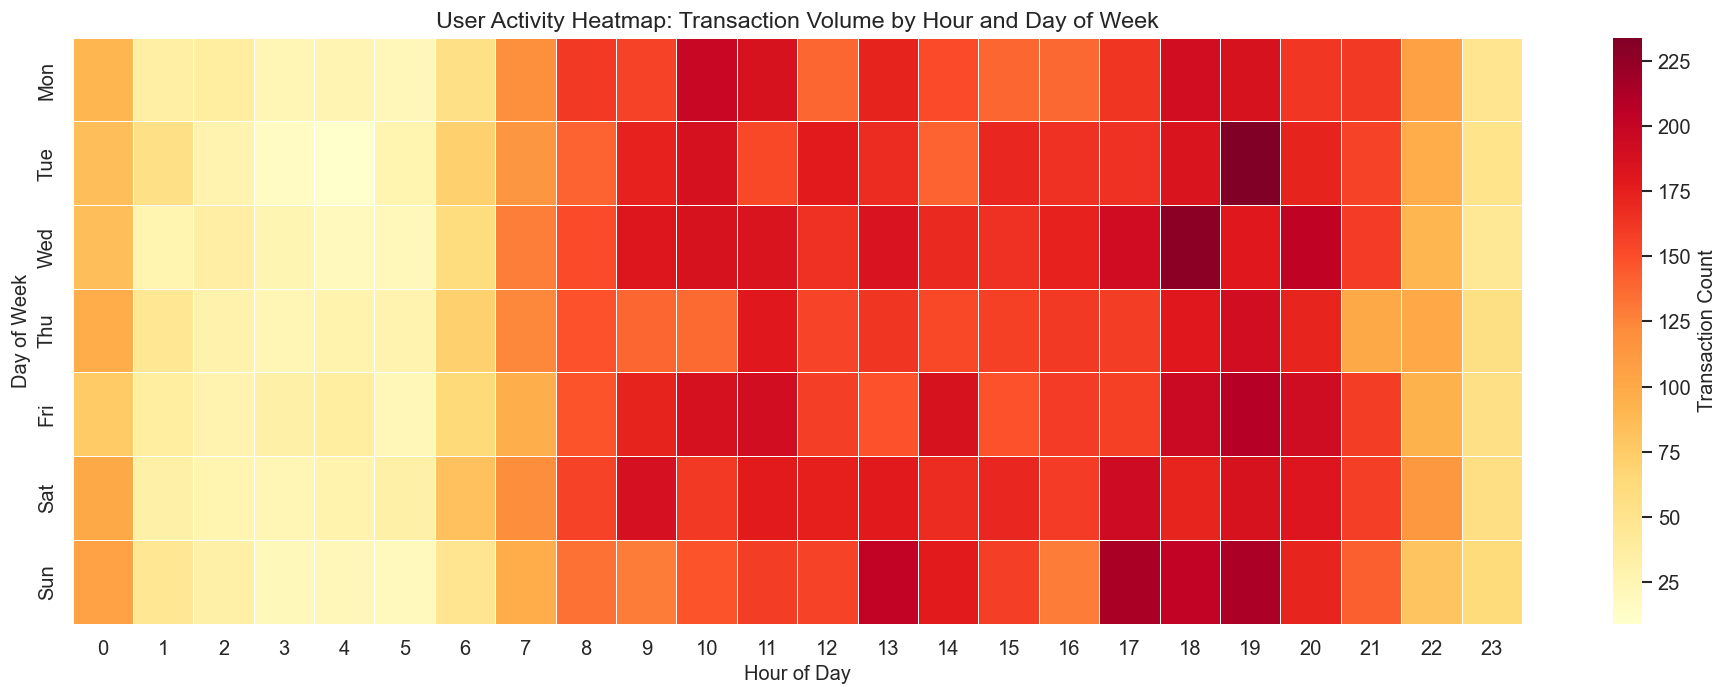

Saved: 09_activity_heatmap.png

Peak activity periods:
  Tue at 19:00 — 234 transactions
  Wed at 18:00 — 227 transactions
  Sun at 17:00 — 214 transactions
  Sun at 19:00 — 213 transactions
  Fri at 19:00 — 208 transactions


In [15]:
# Visualization 9 (Advanced): User Activity Heatmap — Hour × Day of Week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
heatmap_data = df.groupby(['weekday', 'hour']).size().unstack(fill_value=0)
heatmap_data.index = [day_names[i] for i in heatmap_data.index]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt='d', linewidths=0.3,
            cbar_kws={'label': 'Transaction Count'}, ax=ax)
ax.set_title('User Activity Heatmap: Transaction Volume by Hour and Day of Week', fontsize=14)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
fig.savefig(VIZ_DIR / '09_activity_heatmap.png')
plt.show()
print("Saved: 09_activity_heatmap.png")

print("\nPeak activity periods:")
flat = df.groupby(['weekday', 'hour']).size().reset_index(name='count')
top5 = flat.nlargest(5, 'count')
for _, row in top5.iterrows():
    print(f"  {day_names[int(row['weekday'])]} at {int(row['hour']):02d}:00 \u2014 {int(row['count']):,} transactions")

In [16]:
# User Classification: Low / Medium / High activity based on quantiles
q33 = user_agg['txn_count'].quantile(0.33)
q66 = user_agg['txn_count'].quantile(0.66)

def classify_user(count):
    if count <= q33:
        return 'Low'
    elif count <= q66:
        return 'Medium'
    else:
        return 'High'

user_agg['activity_class'] = user_agg['txn_count'].apply(classify_user)

print(f"Classification thresholds:")
print(f"  Low:    txn_count <= {q33:.0f}")
print(f"  Medium: {q33:.0f} < txn_count <= {q66:.0f}")
print(f"  High:   txn_count > {q66:.0f}")
print(f"\nClass distribution:")
print(user_agg['activity_class'].value_counts().to_string())
print(f"\nClass summary statistics:")
user_agg.groupby('activity_class')[['txn_count', 'mean_amount', 'avg_balance', 'avg_monthly_freq']].mean().round(1)

Classification thresholds:
  Low:    txn_count <= 55
  Medium: 55 < txn_count <= 204
  High:   txn_count > 204

Class distribution:
activity_class
High      24
Low       23
Medium    22

Class summary statistics:


,txn_count,mean_amount,avg_balance,avg_monthly_freq
activity_class,,,,
High,725.1,5710.4,15518.1,66.4
Low,31.8,32556.0,70830.7,11.3
Medium,109.0,30269.9,73854.6,23.9


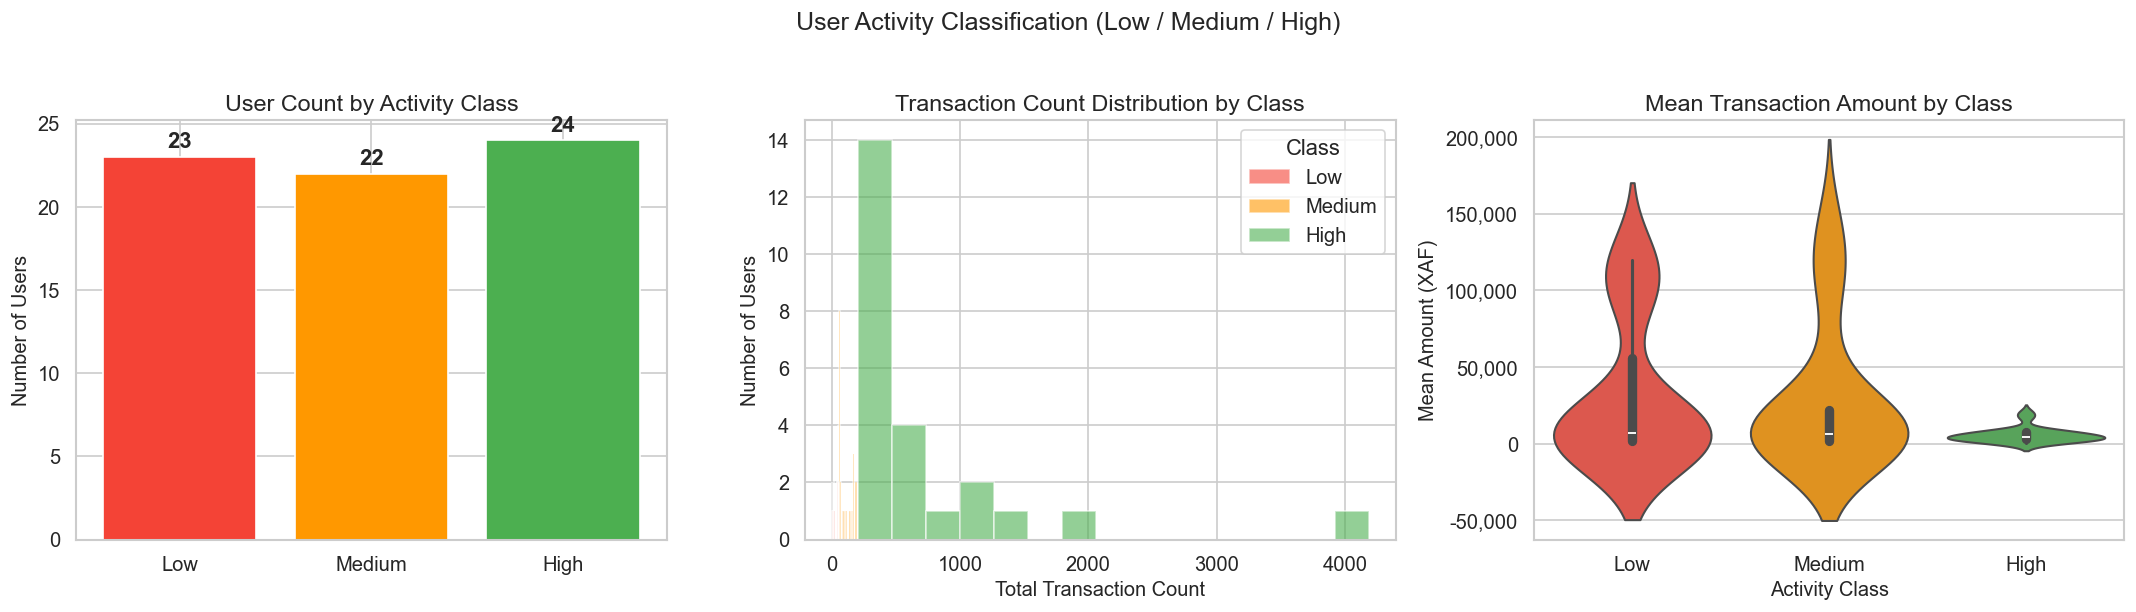

Saved: 10_user_classification.png


In [17]:
# Visualization 10: User Classification Distribution and Profile
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_order = ['Low', 'Medium', 'High']
class_colors = {'Low': '#F44336', 'Medium': '#FF9800', 'High': '#4CAF50'}

# 10a: Class counts
class_counts = user_agg['activity_class'].value_counts().reindex(class_order)
bars = axes[0].bar(class_counts.index, class_counts.values,
                    color=[class_colors[c] for c in class_counts.index], edgecolor='white')
axes[0].set_title('User Count by Activity Class')
axes[0].set_ylabel('Number of Users')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  str(val), ha='center', va='bottom', fontweight='bold')

# 10b: Transaction count distribution per class
for cls in class_order:
    subset = user_agg[user_agg['activity_class'] == cls]
    axes[1].hist(subset['txn_count'], bins=15, alpha=0.6, label=cls, color=class_colors[cls], edgecolor='white')
axes[1].set_title('Transaction Count Distribution by Class')
axes[1].set_xlabel('Total Transaction Count')
axes[1].set_ylabel('Number of Users')
axes[1].legend(title='Class')

# 10c: Mean amount per class (violin)
plot_data = user_agg[['activity_class', 'mean_amount']].copy()
plot_data['activity_class'] = pd.Categorical(plot_data['activity_class'], categories=class_order, ordered=True)
sns.violinplot(data=plot_data, x='activity_class', y='mean_amount', palette=class_colors,
               order=class_order, ax=axes[2], inner='box')
axes[2].set_title('Mean Transaction Amount by Class')
axes[2].set_xlabel('Activity Class')
axes[2].set_ylabel('Mean Amount (XAF)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('User Activity Classification (Low / Medium / High)', fontsize=15, y=1.02)
plt.tight_layout()
fig.savefig(VIZ_DIR / '10_user_classification.png')
plt.show()
print("Saved: 10_user_classification.png")

=== Class Balance Check ===
Total users: 69

  Low     :  23 users (33.3%)
  Medium  :  22 users (31.9%)
  High    :  24 users (34.8%)


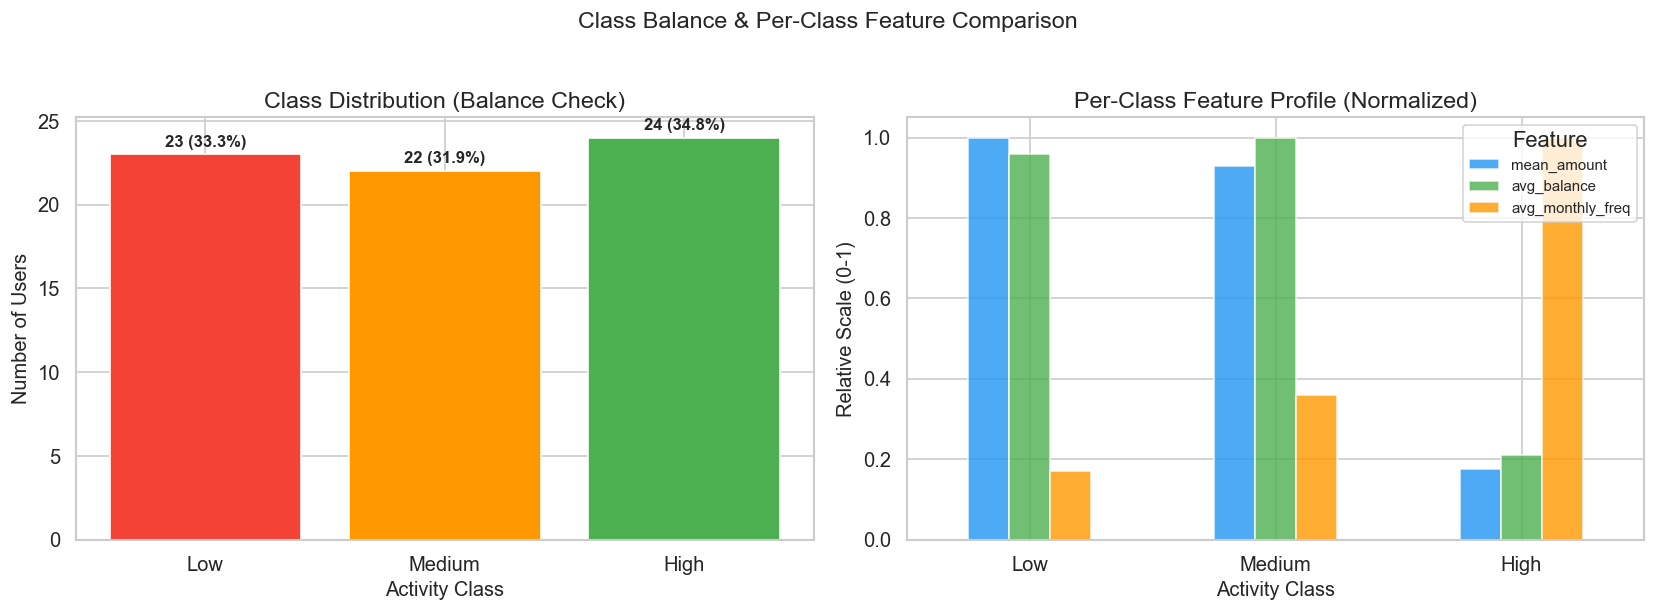


Saved: 11_class_balance_check.png

=== Per-Class Summary (Absolute Values) ===

--- Low Activity ---
  txn_count                :       31.8 ±       17.8
  mean_amount              :   32,556.0 ±   46,879.8
  avg_balance              :   70,830.7 ±  110,840.4
  avg_monthly_freq         :       11.3 ±        9.5
  avg_sr_ratio             :        1.9 ±        1.2

--- Medium Activity ---
  txn_count                :      109.0 ±       50.6
  mean_amount              :   30,269.9 ±   47,125.9
  avg_balance              :   73,854.6 ±  110,538.7
  avg_monthly_freq         :       23.9 ±       14.8
  avg_sr_ratio             :        2.9 ±        1.5

--- High Activity ---
  txn_count                :      725.1 ±      872.1
  mean_amount              :    5,710.4 ±    4,729.3
  avg_balance              :   15,518.1 ±   12,172.9
  avg_monthly_freq         :       66.4 ±       80.8
  avg_sr_ratio             :        3.9 ±        2.1


In [18]:
# Explicit class balance check and per-class feature comparison
print('=== Class Balance Check ===')
print(f'Total users: {len(user_agg)}\n')

for cls in ['Low', 'Medium', 'High']:
    n = (user_agg['activity_class'] == cls).sum()
    pct = n / len(user_agg) * 100
    print(f'  {cls:8s}: {n:3d} users ({pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_order = ['Low', 'Medium', 'High']
class_colors = {'Low': '#F44336', 'Medium': '#FF9800', 'High': '#4CAF50'}
counts = user_agg['activity_class'].value_counts().reindex(class_order)
bars = axes[0].bar(counts.index, counts.values,
                    color=[class_colors[c] for c in counts.index], edgecolor='white')
axes[0].set_title('Class Distribution (Balance Check)')
axes[0].set_ylabel('Number of Users')
axes[0].set_xlabel('Activity Class')
for bar, val in zip(bars, counts.values):
    pct = val / len(user_agg) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{val} ({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=10)

class_means = user_agg.groupby('activity_class')[['mean_amount', 'avg_balance', 'avg_monthly_freq']].mean()
class_means = class_means.reindex(class_order)
class_norm = class_means.div(class_means.max())
class_norm.plot(kind='bar', ax=axes[1], color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='white', alpha=0.8)
axes[1].set_title('Per-Class Feature Profile (Normalized)')
axes[1].set_ylabel('Relative Scale (0-1)')
axes[1].set_xlabel('Activity Class')
axes[1].legend(title='Feature', fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

fig.suptitle('Class Balance & Per-Class Feature Comparison', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(VIZ_DIR / '11_class_balance_check.png')
plt.show()
print('\nSaved: 11_class_balance_check.png')

print('\n=== Per-Class Summary (Absolute Values) ===')
summary = user_agg.groupby('activity_class')[[
    'txn_count', 'mean_amount', 'median_amount', 'avg_balance',
    'avg_monthly_freq', 'avg_sr_ratio', 'avg_velocity_7d', 'pct_weekend'
]].agg(['mean', 'std']).round(1)
for cls in class_order:
    print(f'\n--- {cls} Activity ---')
    for feat in ['txn_count', 'mean_amount', 'avg_balance', 'avg_monthly_freq', 'avg_sr_ratio']:
        m = summary.loc[cls, (feat, 'mean')]
        s = summary.loc[cls, (feat, 'std')]
        print(f'  {feat:25s}: {m:>10,.1f} \u00b1 {s:>10,.1f}')


---

## Section 10: Key Insights & Feature Relevance for User Classification

This final section synthesizes all findings from the exploratory analysis into actionable insights, formulates hypotheses about what drives user behavior, and recommends the most predictive features for the classification model.

This section satisfies **Requirements 3C** (identify at least 5 meaningful patterns, formulate hypotheses, identify predictive features) and **3D** (data storytelling — connect findings to prediction goal).

In [19]:
# Feature relevance analysis: compare feature distributions across activity classes
features_to_compare = ['mean_amount', 'median_amount', 'std_amount', 'avg_balance',
                        'avg_monthly_freq', 'avg_sr_ratio', 'avg_velocity_7d', 'pct_weekend',
                        'total_in', 'total_out']

print("=== Feature Means by Activity Class ===\n")
comparison = user_agg.groupby('activity_class')[features_to_compare].agg(['mean', 'median']).round(1)
for feat in features_to_compare:
    print(f"\n--- {feat} ---")
    for cls in ['Low', 'Medium', 'High']:
        m = comparison.loc[cls, (feat, 'mean')]
        md = comparison.loc[cls, (feat, 'median')]
        print(f"  {cls:8s}: mean={m:>12,.1f}  median={md:>12,.1f}")

=== Feature Means by Activity Class ===


--- mean_amount ---
  Low     : mean=    32,556.0  median=     6,765.0
  Medium  : mean=    30,269.9  median=     6,512.4
  High    : mean=     5,710.4  median=     4,275.1

--- median_amount ---
  Low     : mean=    20,777.2  median=     2,100.0
  Medium  : mean=    20,006.0  median=       925.0
  High    : mean=     1,054.2  median=       500.0

--- std_amount ---
  Low     : mean=    34,813.2  median=    10,175.8
  Medium  : mean=    39,198.0  median=    17,599.2
  High    : mean=    20,997.9  median=    19,122.0

--- avg_balance ---
  Low     : mean=    70,830.7  median=    10,409.1
  Medium  : mean=    73,854.6  median=    16,699.0
  High    : mean=    15,518.1  median=    13,556.1

--- avg_monthly_freq ---
  Low     : mean=        11.3  median=         9.0
  Medium  : mean=        23.9  median=        17.0
  High    : mean=        66.4  median=        48.6

--- avg_sr_ratio ---
  Low     : mean=         1.9  median=         1.7
  Medium  

### Key Insights from EDA

**Insight 1: Heavily right-skewed transaction amounts indicate predominantly micro-transactions.**  
The median transaction amount (500 XAF) is far below the mean (7,454 XAF), with a skewness > 10. Most users perform small, frequent transactions (airtime, small transfers), while a few large payments or transfers pull the mean upward. This suggests that **transaction frequency** is a more robust classification feature than transaction amount.

**Insight 2: Outbound transactions dominate (77.5%), revealing spending-heavy behavior.**  
77.5% of all transactions are outgoing (OUT), driven by transfers (32%), bundle transactions (25%), and airtime purchases (17%). Only deposits and incoming transfers contribute to IN flow. This OUT-heavy pattern is consistent across both operators and suggests that **send/receive ratio** will be a discriminating feature for user segmentation.

**Insight 3: Strong temporal patterns exist — peak activity during evening hours and business days.**  
The activity heatmap reveals peak transaction volume between 17:00–20:00 (post-work hours) across all days. Weekend activity drops modestly (~29% of total vs 71% weekday). This means **hour of day** and **weekday/weekend** features carry signal for behavioral classification.

**Insight 4: The two data sources represent distinct user populations.**  
Anonymized users (18 users) transact with significantly higher amounts (mean 110,932 XAF vs 4,431 XAF) but lower frequency. Original users (51 users) show higher transaction frequency with smaller amounts. This bimodal population reflects genuine behavioral diversity.  
**Modeling safeguard:** The `data_source` feature will be **excluded** from the classification model to ensure the classifier learns behavioral patterns (transaction size, frequency, timing) rather than memorizing which dataset a user came from. This prevents a proxy/shortcut that would not generalize to new users.

**Insight 5: Transaction velocity (7-day rolling window) strongly differentiates activity classes.**  
High-activity users average significantly higher 7-day transaction velocity compared to Low-activity users. Combined with monthly_txn_frequency, these temporal features capture the pace of financial activity that directly defines the Low/Medium/High classification.  
**Note:** Because these features overlap with the classification target, they require careful handling during modeling (see Section 9.4 Data Leakage Awareness).

---

### Hypotheses for Modeling

1. **H1:** Monthly transaction frequency and 7-day velocity will be the most predictive features for user classification
2. **H2:** Mean transaction amount alone is insufficient — it needs to be combined with frequency features
3. **H3:** Send/receive ratio will help separate users who primarily receive money (agents, merchants) from those who primarily send
4. **H4:** Weekend activity proportion captures lifestyle patterns (business vs personal use) that correlate with activity level

---

### Recommended Features for Classification Model

| Priority | Feature | Rationale | Leakage Risk |
|----------|---------|----------|---------------|
| High | mean_amount / median_amount | Transaction size profile | None |
| High | send_receive_ratio | Behavioral pattern indicator | None |
| High | avg_balance (New_balance) | Financial capacity proxy | None |
| Medium | pct_weekend | Lifestyle/usage pattern | None |
| Medium | std_amount | Transaction variability | None |
| Caution | monthly_txn_frequency | Activity level (overlaps target) | High — use with temporal split only |
| Caution | txn_velocity_7d | Recent intensity (overlaps target) | High — use with temporal split only |
| Exclude | data_source | Proxy for dataset identity | Shortcut — always exclude |
| Low | Operator | Limited signal (96% MobileMoney) | None |

---

### EDA Limitations

1. **No demographic data in current analysis.** The assessment requires demographic/contextual data (age, profession, zone, income) collected via questionnaire. This data has not yet been integrated into the EDA. Once the Section 1 questionnaire responses are available, additional analyses should include:
   - Activity class distribution by profession and geographic zone
   - Transaction amount patterns by income range
   - Smartphone ownership vs transaction frequency
   - These demographic features will also be incorporated into the classification model

2. **Skewed financial data.** All financial variables are heavily right-skewed (skewness > 10 for Amount). Log-transformations or robust scaling should be applied before modeling to prevent large-value outliers from dominating.

3. **Imbalanced data source representation.** Original data (51 users, 19,261 txns) vastly outweighs anonymized data (18 users, 1,269 txns). Per-user aggregation mitigates this at the user level (69 users total), but transaction-level analyses are dominated by original-dataset patterns.

4. **Temporal coverage varies by user.** Some users have 3 months of data while others have up to 36 months. Features like `monthly_txn_frequency` partially normalize this, but users with short histories may have less stable behavioral profiles.

5. **Data leakage potential.** The classification target (total transaction count) overlaps with frequency-based features. Section 4 must use either temporal train/test splits or exclude direct frequency features to ensure valid evaluation.

In [20]:
# Save user classification for modeling phase
output_path = Path('../Data/output/user_classification.csv')
user_agg.to_csv(output_path, index=False)
print(f"User classification saved to: {output_path.resolve()}")
print(f"  {len(user_agg)} users classified: {user_agg['activity_class'].value_counts().to_dict()}")

print("\n=== EDA Summary ===")
print(f"Total transactions analyzed: {len(df):,}")
print(f"Unique users: {df['UserId'].nunique()}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Visualizations generated: 10 (saved to {VIZ_DIR.resolve()})")
print(f"Key insights identified: 5")
print(f"Hypotheses formulated: 4")
print(f"Prediction target: User Activity Classification (Low/Medium/High)")

User classification saved to: C:\Users\ghisl\Documents\DataScience_Final_Project\Data\output\user_classification.csv
  69 users classified: {'High': 24, 'Low': 23, 'Medium': 22}

=== EDA Summary ===
Total transactions analyzed: 20,530
Unique users: 69
Date range: 2023-03-10 to 2026-03-28
Visualizations generated: 10 (saved to C:\Users\ghisl\Documents\DataScience_Final_Project\3_EDA\visualizations)
Key insights identified: 5
Hypotheses formulated: 4
Prediction target: User Activity Classification (Low/Medium/High)
